In [2]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import models, layers

In [3]:
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from skimage.transform import resize

In [4]:
import seaborn as sns

In [5]:
(train_images,train_labels),(test_images,test_labels)=cifar10.load_data()

In [6]:
train_images[0].min()

0

In [7]:

train_images=train_images.astype('float32')/255
test_images=test_images.astype('float32')/255


Data Augumentation
If we don't have enough train data (images) to work on then we generate more data using data augumentation. It flips and rotates images randomly

In [8]:
train_images = np.array([resize(img, (28, 28), mode='reflect') for img in train_images])
test_images = np.array([resize(img, (28, 28), mode='reflect') for img in test_images])

# Convert to grayscale
train_images = np.mean(train_images, axis=-1, keepdims=True)
test_images = np.mean(test_images, axis=-1, keepdims=True)

In [9]:
data_augmentation=tf.keras.Sequential([layers.RandomRotation(0.1),
                                      layers.RandomFlip(),
                                      layers.RandomZoom(0.1),
                                      layers.RandomTranslation(0.1,0.1)])

In [10]:
def create_model():
    inputs = keras.Input(shape=(28,28,1))
    x = data_augmentation(inputs)

    x = keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPool2D(2)(x)
    x = keras.layers.SpatialDropout2D(0.2)(x)

    x = keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPool2D(2)(x)
    x = keras.layers.SpatialDropout2D(0.2)(x)

    residual = x
    x = keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.add([x,residual])

    
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(256, activation="relu")(x)
    outputs = keras.layers.Dense(10, activation="softmax")(x)

    model =keras.Model(inputs, outputs)
    return model

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

In [12]:
callbacks = [EarlyStopping(patience=10, restore_best_weights= True)]

In [13]:
model=create_model()

In [14]:
from tensorflow.keras.optimizers import Adam

In [15]:
model.compile(optimizer=Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",metrics=['accuracy'])


In [18]:
history = model.fit(train_images, train_labels, callbacks=callbacks, epochs=20, batch_size=8,validation_data=(test_images, test_labels) )

Epoch 1/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 742s 119ms/step - accuracy: 0.5496 - loss: 1.2729 - val_accuracy: 0.5699 - val_loss: 1.2997
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 452s 72ms/step - accuracy: 0.5534 - loss: 1.2713 - val_accuracy: 0.5741 - val_loss: 1.2856
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 479s 77ms/step - accuracy: 0.5474 - loss: 1.2784 - val_accuracy: 0.5511 - val_loss: 1.4782
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2495s 399ms/step - accuracy: 0.5553 - loss: 1.2635 - val_accuracy: 0.5776 - val_loss: 1.3056
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 373s 60ms/step - accuracy: 0.5557 - loss: 1.2630 - val_accuracy: 0.5884 - val_loss: 1.2693
Epoch 6/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 329s 53ms/step - accuracy: 0.5549 - loss: 1.2495 - val_accuracy: 0.5507 - val_loss: 1.4121
Epoch 7/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 452s 72ms/step - accuracy: 0.5583 - loss: 1.2528 - val_accuracy: 0.5758 - val_loss: 1.3472
Epoch 8/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 433s 69ms/step - accurac

In [19]:
from sklearn.metrics import classification_report

In [20]:
import pprint

In [21]:
y_pred= model.predict(test_images).argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step


In [22]:
pprint.pprint(classification_report(test_labels, y_pred))

('              precision    recall  f1-score   support\n'
 '\n'
 '           0       0.75      0.68      0.71      1000\n'
 '           1       0.79      0.86      0.82      1000\n'
 '           2       0.50      0.51      0.51      1000\n'
 '           3       0.59      0.18      0.27      1000\n'
 '           4       0.70      0.34      0.46      1000\n'
 '           5       0.66      0.50      0.57      1000\n'
 '           6       0.50      0.80      0.62      1000\n'
 '           7       0.60      0.73      0.66      1000\n'
 '           8       0.72      0.84      0.77      1000\n'
 '           9       0.57      0.84      0.68      1000\n'
 '\n'
 '    accuracy                           0.63     10000\n'
 '   macro avg       0.64      0.63      0.61     10000\n'
 'weighted avg       0.64      0.63      0.61     10000\n')


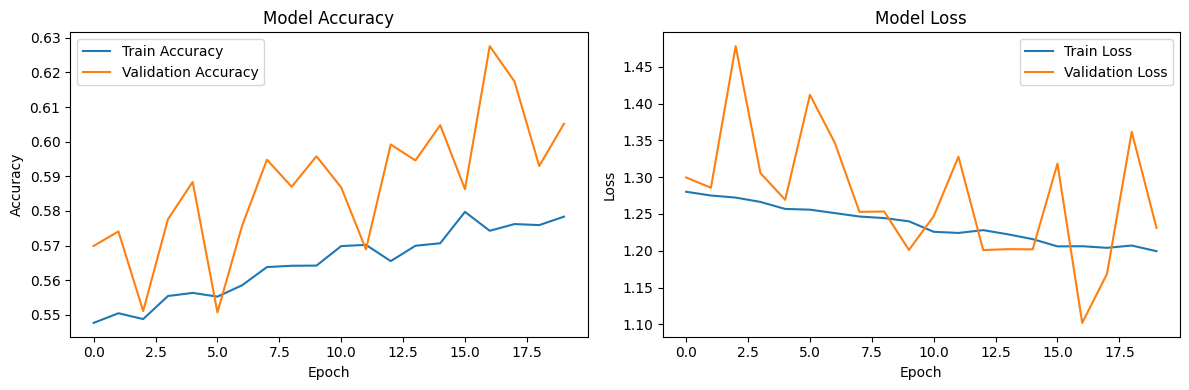

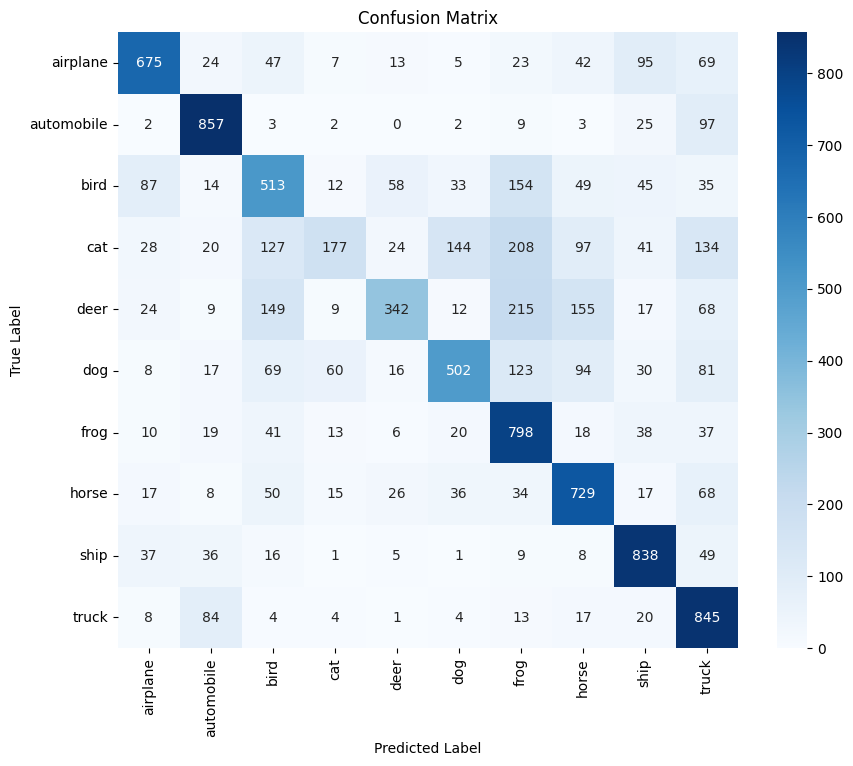

In [29]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = tf.math.confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Make predictions and plot confusion matrix
class_names = '''airplane automobile bird cat deer dog frog horse ship truck'''.split()
plot_confusion_matrix(test_labels, y_pred, class_names)

In [30]:
import numpy as np
from PIL import Image
import tensorflow as tf

def preprocess_image(image_path):
    # Open the image
    img = Image.open(image_path)
    
    # Convert to grayscale if it's not already
    if img.mode != 'L':
        img = img.convert('L')
    
    # Resize to 28x28 pixels
    img = img.resize((28, 28))
    
    # Convert to numpy array and normalize
    img_array = np.array(img).astype('float32') / 255.0
    
    # Reshape to (1, 28, 28, 1) for model input
    img_array = img_array.reshape(1, 28, 28, 1)
    
    return img_array

In [32]:
def predict_class(model, image_array):
    # Make prediction
    prediction = model.predict(image_array)
    print(prediction)
    # Get the class with highest probability
    class_index = np.argmax(prediction)

    print(class_index)
    
    # Define class names
    class_names = '''airplane automobile bird cat deer dog frog horse ship truck'''.split()

    print(len(class_names))
    
    # Get the predicted class name
    predicted_class = class_names[class_index]
    
    # Get the confidence (probability)
    confidence = prediction[0][class_index]
    
    return predicted_class, confidence

In [33]:
# Assume 'model' is your trained model
# Replace 'path_to_your_image.jpg' with the actual path to your image
image_path = 'deer.jpeg'

# Preprocess the image
processed_image = preprocess_image(image_path)

# Predict the class
predicted_class, confidence = predict_class(model, processed_image)

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[[1.0774433e-02 2.1660941e-04 1.3398446e-01 1.1676463e-02 4.8439890e-01
  9.0816729e-03 3.3855993e-01 5.4696482e-03 3.8213709e-03 2.0165730e-03]]
4
10
Predicted class: deer
Confidence: 0.48
